/tmp/ipykernel_727916/2361091908.py:9: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  set_of_all_points= np.row_stack((focal, nearby))


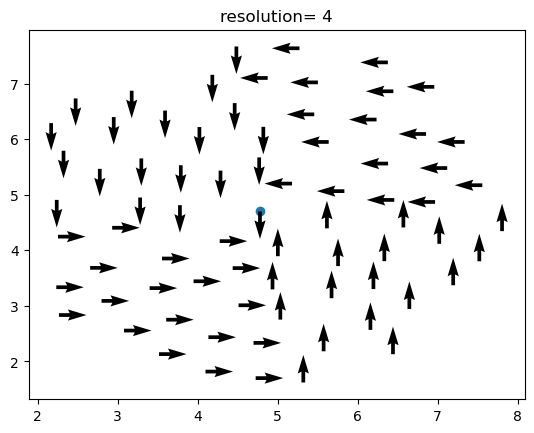

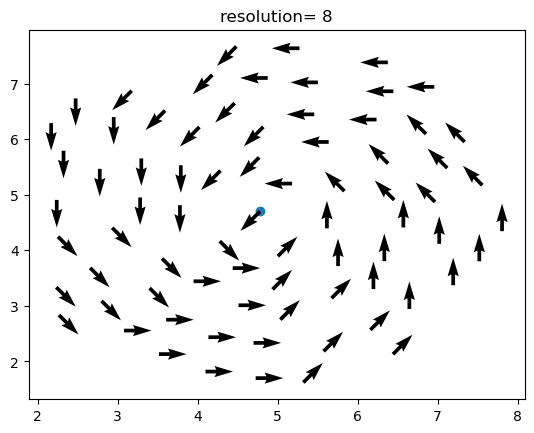

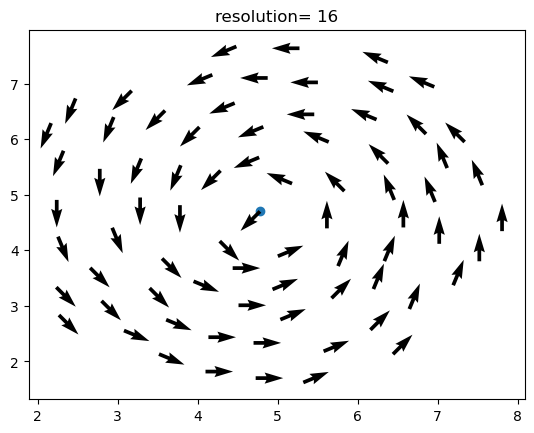

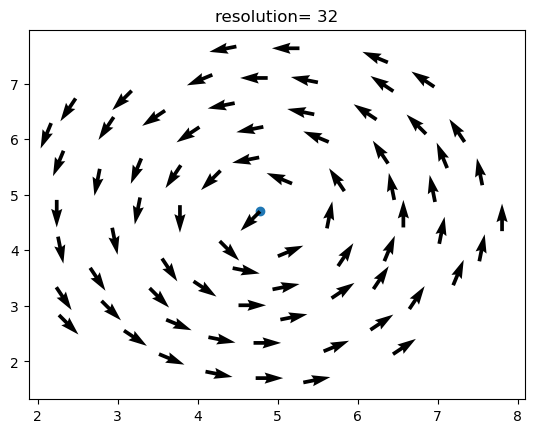

In [6]:
import the_cocktail_party_nightmare as CPN
import matplotlib.pyplot as plt
import numpy as np
from create_milling_swarming_angles import generate_heading_vectors_concentric_circles
import math

sim_data={}; sim_data["noncentral_bat"]=False
nearby, focal= CPN.generate_surroundpoints_w_poissondisksampling(npoints=75, nbr_distance=0.5, **sim_data)
set_of_all_points= np.row_stack((focal, nearby))



def compute_u_v_for_plotting(points, angles):
    u_v_s= []; i=0
    for angle in angles:
        point= points[i]
        angle_in_radians= math.radians(angle)
        U= np.cos(angle_in_radians)
        V= np.sin(angle_in_radians)
        
        u_v_s.append([point[0], point[1], U, V])
        i+=1

    return np.array(u_v_s)

resolutions= [4, 8, 16, 32]
for resolution in resolutions:
    vector_angles= generate_heading_vectors_concentric_circles(set_of_all_points=set_of_all_points, resolution=resolution)
    u_v_s= compute_u_v_for_plotting(set_of_all_points, vector_angles)

    plt.scatter(focal[0], focal[1])
    for u_v in u_v_s:
        plt.quiver(*u_v)
    plt.title(f'resolution= {resolution}')
    plt.show()
